# Compare multi-label sound models on Apple Silicon

## tl;dr

This experiment runs the same mixed WAV through Apple SoundAnalysis, AST, and EfficientAT. It reports independent scores for dog, barking, race car, engine, and engine revving in overlapping time windows. Use the maximum-score summary and timeline below to compare sensitivity; scores are not calibrated across models.

## Context & Methods

The goal is **multi-label audio tagging**, not source separation. Every model sees 3-second windows with a 1.5-second hop. Results are mapped to five shared canonical labels so the tables are comparable.

### Key Assumptions

- Short overlapping windows are more likely to preserve a brief bark than a whole-file average.
- Scores should be compared within a model, not directly between models.
- AST uses PyTorch MPS when available. EfficientAT uses CPU because its upstream project does not officially support MPS.
- The first AST and EfficientAT runs download their public checkpoints.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
import subprocess
import sys

from IPython.display import Audio, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "sound_model_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    raise RuntimeError("Run this notebook from the project or notebook directory")

sys.path.insert(0, str(PROJECT_ROOT / "src"))

AUDIO_PATH = PROJECT_ROOT / "samples/audio/challenge_dog_over_race_car.wav"
WINDOW_SECONDS = 3.0
HOP_SECONDS = 1.5
RUN_AST = True
RUN_EFFICIENTAT = True
CANONICAL_LABELS = ["dog", "dog_bark", "race_car", "engine", "engine_revving"]

if not AUDIO_PATH.is_file():
    raise FileNotFoundError(AUDIO_PATH)

print(f"project: {PROJECT_ROOT}")
print(f"audio:   {AUDIO_PATH}")
print(f"MPS available: {torch.backends.mps.is_available()}")

project: /Users/kafka/Github_/odia-project/detect_objects
audio:   /Users/kafka/Github_/odia-project/detect_objects/samples/audio/challenge_dog_over_race_car.wav
MPS available: True


## Data

Inspect and listen to the exact input used by all three backends.

In [2]:
audio_waveform, audio_sample_rate = sf.read(AUDIO_PATH, always_2d=False)
audio_channels = 1 if audio_waveform.ndim == 1 else audio_waveform.shape[1]
audio_duration = len(audio_waveform) / audio_sample_rate

display(pd.DataFrame([{
    "path": str(AUDIO_PATH),
    "duration_seconds": round(audio_duration, 3),
    "sample_rate": audio_sample_rate,
    "channels": audio_channels,
}]))
display(Audio(filename=str(AUDIO_PATH)))

,path,duration_seconds,sample_rate,channels
0,/Users/kafka/Github_/odia-project/detect_objec...,12.0,16000,1


## Results

### 1. Apple SoundAnalysis

Apple's native classifier normally hides scores below the configured event threshold. For comparison, this cell retains every native classification and then selects the five shared labels.

In [3]:
from dataclasses import replace

from detect_objects.models.model_config import load_apple_sound_analysis_config
from detect_objects.models.sound.apple_sound_analysis import AppleSoundAnalysisClassifier

apple_config = load_apple_sound_analysis_config()
apple_classifier = AppleSoundAnalysisClassifier(apple_config)
apple_known_labels = apple_classifier.known_labels
apple_config = replace(
    apple_config,
    window_seconds=WINDOW_SECONDS,
    overlap=1.0 - HOP_SECONDS / WINDOW_SECONDS,
    thresholds={label: 0.0 for label in apple_known_labels},
    top_k=len(apple_known_labels),
)

apple_label_map = {
    "dog": "dog",
    "dog_bark": "dog_bark",
    "race_car": "race_car",
    "engine": "engine",
    "engine_revving": "engine_accelerating_revving",
}
apple_records = []
for window in AppleSoundAnalysisClassifier(apple_config).classify_file(AUDIO_PATH):
    native_scores = {item.label: item.confidence for item in window.predictions}
    for canonical_label, native_label in apple_label_map.items():
        apple_records.append({
            "model": "Apple SoundAnalysis",
            "start_seconds": window.start_seconds,
            "end_seconds": window.end_seconds,
            "label": canonical_label,
            "score": native_scores.get(native_label, 0.0),
        })

apple_frame = pd.DataFrame(apple_records)
display(apple_frame.pivot(index=["start_seconds", "end_seconds"], columns="label", values="score").round(3))

,label,dog,dog_bark,engine,engine_revving,race_car
start_seconds,end_seconds,,,,,
0.0,3.0,0.024,0.013,0.069,0.043,0.022
1.5,4.5,0.017,0.002,0.042,0.033,0.023
3.0,6.0,0.004,0.001,0.622,0.700,0.558
4.5,7.5,0.029,0.016,0.620,0.692,0.534
6.0,9.0,0.041,0.020,0.619,0.731,0.533
7.5,10.5,0.004,0.002,0.654,0.741,0.448
9.0,12.0,0.012,0.003,0.285,0.372,0.315


### 2. Audio Spectrogram Transformer (AST)

AST produces 527 AudioSet logits. Applying sigmoid yields independent multi-label scores. The model runs through PyTorch MPS on Apple Silicon and falls back to CPU elsewhere.

In [4]:
ast_records = []
if RUN_AST:
    from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

    ast_model_id = "MIT/ast-finetuned-audioset-10-10-0.4593"
    ast_device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    ast_extractor = AutoFeatureExtractor.from_pretrained(ast_model_id)
    ast_model = AutoModelForAudioClassification.from_pretrained(ast_model_id).to(ast_device).eval()

    ast_audio = audio_waveform.mean(axis=1) if audio_waveform.ndim > 1 else audio_waveform
    ast_window_samples = int(WINDOW_SECONDS * audio_sample_rate)
    ast_hop_samples = int(HOP_SECONDS * audio_sample_rate)
    ast_starts = list(range(0, len(ast_audio) - ast_window_samples + 1, ast_hop_samples))
    ast_chunks = [ast_audio[start:start + ast_window_samples] for start in ast_starts]
    ast_inputs = ast_extractor(
        ast_chunks,
        sampling_rate=audio_sample_rate,
        return_tensors="pt",
        padding=True,
    )
    ast_inputs = {name: value.to(ast_device) for name, value in ast_inputs.items()}

    with torch.inference_mode():
        ast_scores = torch.sigmoid(ast_model(**ast_inputs).logits).cpu()

    ast_native_labels = {label: int(index) for index, label in ast_model.config.id2label.items()}
    ast_label_map = {
        "dog": "Dog",
        "dog_bark": "Bow-wow",
        "race_car": "Race car, auto racing",
        "engine": "Engine",
        "engine_revving": "Accelerating, revving, vroom",
    }
    for row_index, (start_sample, window_scores) in enumerate(zip(ast_starts, ast_scores)):
        start_seconds = start_sample / audio_sample_rate
        for canonical_label, native_label in ast_label_map.items():
            ast_records.append({
                "model": "AST (MPS)" if ast_device.type == "mps" else "AST (CPU)",
                "start_seconds": start_seconds,
                "end_seconds": start_seconds + WINDOW_SECONDS,
                "label": canonical_label,
                "score": window_scores[ast_native_labels[native_label]].item(),
            })

ast_frame = pd.DataFrame(ast_records)
display(ast_frame.pivot(index=["start_seconds", "end_seconds"], columns="label", values="score").round(3))

/Users/kafka/Github_/odia-project/detect_objects/.venv/lib/python3.11/site-packages/transformers/audio_utils.py:559: UserWarning: At least one mel filter has all zero values. The value for `num_mel_filters` (128) may be set too high. Or, the value for `num_frequency_bins` (257) may be set too low.
  warnings.warn(


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

,label,dog,dog_bark,engine,engine_revving,race_car
start_seconds,end_seconds,,,,,
0.0,3.0,0.003,0.001,0.010,0.003,0.000
1.5,4.5,0.002,0.000,0.025,0.010,0.001
3.0,6.0,0.001,0.000,0.036,0.255,0.008
4.5,7.5,0.138,0.075,0.023,0.170,0.061
6.0,9.0,0.097,0.077,0.024,0.142,0.030
7.5,10.5,0.001,0.000,0.023,0.095,0.012
9.0,12.0,0.003,0.001,0.009,0.048,0.036


### 3. EfficientAT `dymn10_as`

EfficientAT is executed in a subprocess so its extra `librosa` and `torchaudio` dependencies remain temporary. Its source and 41 MB checkpoint are stored below the Git-ignored `model_artifacts/audio/` directory.

In [5]:
efficientat_records = []
if RUN_EFFICIENTAT:
    efficientat_dir = PROJECT_ROOT / "model_artifacts/audio/efficientat_source"
    if not (efficientat_dir / ".git").is_dir():
        efficientat_dir.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/fschmid56/EfficientAT.git", str(efficientat_dir)],
            check=True,
            capture_output=True,
            text=True,
        )

    efficientat_script = r'''
from contextlib import redirect_stdout
import io
import json
import os

import librosa
import torch

from helpers.utils import labels
from models.dymn.model import get_model
from models.preprocess import AugmentMelSTFT

with redirect_stdout(io.StringIO()):
    model = get_model(pretrained_name="dymn10_as")
    mel = AugmentMelSTFT(n_mels=128, sr=32000, win_length=800, hopsize=320).eval()
model.eval()
waveform, _ = librosa.load(os.environ["AUDIO_PATH"], sr=32000, mono=True)
waveform = torch.from_numpy(waveform)
window_seconds = float(os.environ["WINDOW_SECONDS"])
hop_seconds = float(os.environ["HOP_SECONDS"])
window_samples = int(window_seconds * 32000)
hop_samples = int(hop_seconds * 32000)
label_map = {
    "dog": "Dog",
    "dog_bark": "Bark",
    "race_car": "Race car, auto racing",
    "engine": "Engine",
    "engine_revving": "Accelerating, revving, vroom",
}
indices = {canonical: labels.index(native) for canonical, native in label_map.items()}
records = []
with torch.inference_mode():
    for start in range(0, len(waveform) - window_samples + 1, hop_samples):
        spectrogram = mel(waveform[start:start + window_samples].unsqueeze(0))
        logits, _ = model(spectrogram.unsqueeze(0))
        scores = torch.sigmoid(logits[0].float())
        start_seconds = start / 32000
        for canonical, index in indices.items():
            records.append({
                "model": "EfficientAT (CPU)",
                "start_seconds": start_seconds,
                "end_seconds": start_seconds + window_seconds,
                "label": canonical,
                "score": scores[index].item(),
            })
print(json.dumps(records))
'''
    efficientat_environment = os.environ.copy()
    efficientat_environment.update({
        "AUDIO_PATH": str(AUDIO_PATH),
        "WINDOW_SECONDS": str(WINDOW_SECONDS),
        "HOP_SECONDS": str(HOP_SECONDS),
    })
    completed = subprocess.run(
        [
            "uv", "run", "--project", str(PROJECT_ROOT),
            "--with", "librosa", "--with", "torchaudio",
            "python", "-c", efficientat_script,
        ],
        cwd=efficientat_dir,
        env=efficientat_environment,
        check=True,
        capture_output=True,
        text=True,
    )
    efficientat_records = json.loads(completed.stdout)

efficientat_frame = pd.DataFrame(efficientat_records)
display(efficientat_frame.pivot(index=["start_seconds", "end_seconds"], columns="label", values="score").round(3))

,label,dog,dog_bark,engine,engine_revving,race_car
start_seconds,end_seconds,,,,,
0.0,3.0,0.007,0.000,0.012,0.004,0.000
1.5,4.5,0.005,0.000,0.024,0.007,0.001
3.0,6.0,0.005,0.000,0.057,0.213,0.006
4.5,7.5,0.032,0.005,0.016,0.076,0.028
6.0,9.0,0.045,0.010,0.041,0.085,0.012
7.5,10.5,0.002,0.000,0.027,0.093,0.025
9.0,12.0,0.003,0.000,0.019,0.067,0.019


### 4. Compare maximum window scores

For each model and canonical label, retain the highest score and the time window where it occurred. This preserves short events that would be diluted by whole-file averaging.

In [6]:
all_results = pd.concat(
    [frame for frame in (apple_frame, ast_frame, efficientat_frame) if not frame.empty],
    ignore_index=True,
)
winning_rows = (
    all_results.loc[all_results.groupby(["model", "label"])["score"].idxmax()]
    .sort_values(["model", "label"])
)
maximum_scores = winning_rows.pivot(index="model", columns="label", values="score")[CANONICAL_LABELS]
display(maximum_scores.round(3))

winning_windows = winning_rows[["model", "label", "score", "start_seconds", "end_seconds"]]
display(winning_windows.round(3).reset_index(drop=True))

label,dog,dog_bark,race_car,engine,engine_revving
model,,,,,
AST (MPS),0.138,0.077,0.061,0.036,0.255
Apple SoundAnalysis,0.041,0.020,0.558,0.654,0.741
EfficientAT (CPU),0.045,0.010,0.028,0.057,0.213


,model,label,score,start_seconds,end_seconds
0,AST (MPS),dog,0.138,4.5,7.5
1,AST (MPS),dog_bark,0.077,6.0,9.0
2,AST (MPS),engine,0.036,3.0,6.0
3,AST (MPS),engine_revving,0.255,3.0,6.0
4,AST (MPS),race_car,0.061,4.5,7.5
5,Apple SoundAnalysis,dog,0.041,6.0,9.0
6,Apple SoundAnalysis,dog_bark,0.020,6.0,9.0
7,Apple SoundAnalysis,engine,0.654,7.5,10.5
8,Apple SoundAnalysis,engine_revving,0.741,7.5,10.5
9,Apple SoundAnalysis,race_car,0.558,3.0,6.0


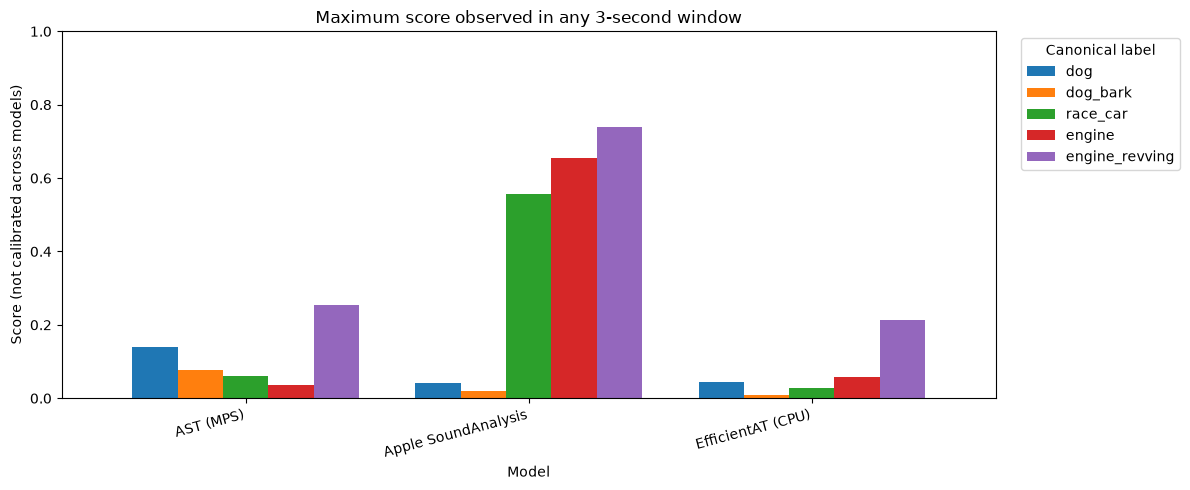

In [7]:
axes = maximum_scores.plot.bar(figsize=(12, 5), width=0.8)
axes.set_title("Maximum score observed in any 3-second window")
axes.set_xlabel("Model")
axes.set_ylabel("Score (not calibrated across models)")
axes.set_ylim(0, 1)
axes.legend(title="Canonical label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Checks

These assertions catch incomplete model output, missing target labels, and invalid score ranges.

In [8]:
expected_models = {"Apple SoundAnalysis"}
if RUN_AST:
    expected_models.add("AST (MPS)" if torch.backends.mps.is_available() else "AST (CPU)")
if RUN_EFFICIENTAT:
    expected_models.add("EfficientAT (CPU)")

assert set(all_results["model"]) == expected_models
assert set(all_results["label"]) == set(CANONICAL_LABELS)
assert all_results["score"].between(0.0, 1.0).all()
assert not all_results[["start_seconds", "end_seconds", "score"]].isna().any().any()
print(f"checks passed: {len(all_results)} model/window/label scores")

checks passed: 105 model/window/label scores


## Takeaways

- All three backends return simultaneous multi-label scores; no separator is required.
- Apple SoundAnalysis is the lightest native baseline and is especially strong for the race-car/engine family in this sample.
- AST is more sensitive to the quieter dog in the difficult mixed window and already runs on MPS.
- EfficientAT is much smaller than AST and strong on whole-clip vehicle tagging, but its official implementation is CPU/CUDA-oriented.
- Keep display thresholds separate from application-event thresholds. Low scores are still valuable when comparing difficult mixtures.